# Lets-Plot Themes

In [1]:
import numpy as np
import pandas as pd
from PIL import Image

from lets_plot import *
from lets_plot.geo_data import *
from lets_plot.bistro.corr import *

The geodata is provided by © OpenStreetMap contributors and is made available here under the Open Database License (ODbL).



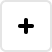
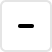
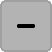
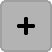
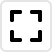
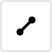
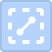
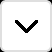
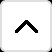
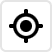
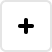
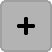
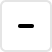
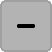
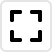
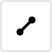
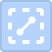
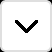
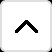
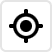

In [2]:
LetsPlot.setup_html()

### Preparation

In [3]:
w, h = 400, 300

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/mpg.csv")
gdf = geocode_countries().get_boundaries(3)
img = Image.open("images/fisher_boat.png")

In [5]:
p_plot = ggplot(df) + geom_point(aes('cty', 'hwy'))
p_plot

In [6]:
b_plot = ggplot(df) + geom_bar(aes('fl', color='fl', fill='fl'))
b_plot

In [7]:
f_plot = b_plot + facet_grid(x='year')
f_plot

In [8]:
c_plot = corr_plot(df.select_dtypes(include=np.number), flip=False).points().build()
c_plot

In [9]:
g_plot = ggplot() + geom_map(data=gdf, color='white', fill='black')
g_plot


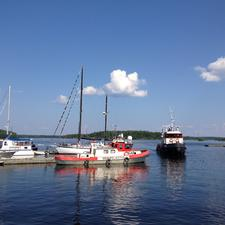

In [10]:
i_plot = ggplot() + geom_imshow(image_data=np.asarray(img))
i_plot

### Elements

In [11]:
e_blank = element_blank()
e_line = element_line(color='#de2d26', size=4)
e_line2 = element_line(color='#fcae91', size=1)
e_line3 = element_line(size=4)
e_rect = element_rect(color='#2c7fb8', fill='#edf8b1', size=2)
e_text = element_text(color='#31a354')
e_geom = element_geom(pen='#2c7fb8')

### Themes

In [12]:
gggrid([
    p_plot + ggtitle("default: theme_minimal2()"),
    p_plot + ggtitle("theme_none()") + theme_none(),
    p_plot + ggtitle("theme_void()") + theme_void(),
    p_plot + ggtitle("theme_minimal()") + theme_minimal(),
    p_plot + ggtitle("theme_classic()") + theme_classic(),
    p_plot + ggtitle("theme_grey()") + theme_grey(),
    p_plot + ggtitle("theme_light()") + theme_light(),
    p_plot + ggtitle("theme_bw()") + theme_bw(),
], ncol=2)

### Custom Theme

In [13]:
def orange_theme():
    yellow_light = '#ffffcc'
    orange_dark = '#7f2704'
    orange_normal = '#f16913'
    orange_light = '#fff5eb'
    return theme_none() + theme(
        line=element_line(color=orange_normal, size=2),
        rect=element_rect(color=orange_normal, fill=orange_light, size=2),
        text=element_text(color=orange_dark),
        axis_ontop=True,
        axis_ticks=element_line(color=orange_normal, size=1),
        axis_ticks_length=7,
        legend_background=element_rect(size=1),
        legend_position='bottom',
        panel_grid_major=element_line(color=orange_normal, size=.5),
        panel_grid_minor='blank',
        plot_background=element_rect(fill=yellow_light, size=1),
        axis_tooltip=element_rect(color=orange_dark)
    )

bunch = GGBunch()
bunch.add_plot(p_plot + orange_theme() + ggtitle("Point plot example"), \
               0, 0, w, h)
bunch.add_plot(b_plot + orange_theme() + ggtitle("Bar plot example"), \
               w, 0, w, h)
bunch.add_plot(c_plot + orange_theme() + ggtitle("Corr plot example"), \
               0, h, w, h)
bunch.add_plot(g_plot + orange_theme() + ggtitle("Map plot example"), \
               w, h, w, h)
bunch.show()

### Theme Parameters

In [14]:
bunch = GGBunch()
for i, (param, element, element_name) in enumerate([('axis_title_x', e_text, 'e_text'), \
                                                    ('axis_text_x', e_text, 'e_text'), \
                                                    ('axis_ticks_x', e_line, 'e_line'), \
                                                    ('axis_line_x', e_line, 'e_line')]):
    bunch.add_plot(p_plot + ggtitle("{0}=element_blank".format(param)) + theme(**{param: element_blank()}), \
                   0, i * h, w, h)
    bunch.add_plot(p_plot + ggtitle("{0}={1}".format(param, element_name)) + theme(**{param: element}), \
                   w, i * h, w, h)
bunch.show()

In [15]:
b_plot + \
    ggtitle("Place legend") + \
    theme(legend_position=[1, 1], legend_justification=[1, 1], legend_direction='vertical')

In [16]:
bunch = GGBunch()
bunch.add_plot(p_plot + ggtitle("axis_tooltip_x=e_blank") + theme(axis_tooltip_x=e_blank), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("axis_tooltip_x=e_rect") + theme(axis_tooltip_x=e_rect), \
               w, 0, w, h)
bunch.show()

In [17]:
bunch = GGBunch()
bunch.add_plot(p_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("line=e_line") + theme(line=e_line), \
               w, 0, w, h)
bunch.show()

In [18]:
bunch = GGBunch()
bunch.add_plot(b_plot + ggtitle("theme_none()") + theme_none(), \
               0, 0, w, h)
bunch.add_plot(b_plot + ggtitle("theme_none + rect") + theme_none() + theme(rect=e_rect), \
               w, 0, w, h)
bunch.show()

In [19]:
bunch = GGBunch()
bunch.add_plot(f_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(f_plot + ggtitle("text=e_text") + theme(text=e_text), \
               w, 0, w, h)
bunch.add_plot(f_plot + ggtitle("legend_text=e_text") + theme(legend_text=e_text), \
               0, h, w, h)
bunch.add_plot(f_plot + ggtitle("strip_text=e_text") + theme(strip_text=e_text), \
               w, h, w, h)
bunch.show()

In [20]:
bunch = GGBunch()
bunch.add_plot(b_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(b_plot + ggtitle("title=e_text") + theme(title=e_text), \
               w, 0, w, h)
bunch.add_plot(b_plot + ggtitle("plot_title=e_text") + theme(plot_title=e_text), \
               0, h, w, h)
bunch.add_plot(b_plot + ggtitle("legend_title=e_text") + theme(legend_title=e_text), \
               w, h, w, h)
bunch.show()

In [21]:
bunch = GGBunch()
bunch.add_plot(p_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("axis=e_blank") + theme(axis=e_blank), \
               w, 0, w, h)
bunch.add_plot(p_plot + ggtitle("axis=e_line") + theme(axis=e_line), \
               0, h, w, h)
bunch.add_plot(p_plot + ggtitle("axis=e_text") + theme(axis=e_text), \
               w, h, w, h)
bunch.show()

In [22]:
bunch = GGBunch()
bunch.add_plot(p_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("panel_background=e_rect") + theme(panel_background=e_rect), \
               w, 0, w, h)
bunch.show()

In [23]:
bunch = GGBunch()
bunch.add_plot(b_plot + ggtitle("panel_grid=e_blank") + theme(panel_grid=e_blank), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("panel_grid=e_line") + theme(panel_grid=e_line), \
               w, 0, w, h)
bunch.add_plot(p_plot + ggtitle("panel_grid_major=e_line, panel_grid_minor=element_line") + \
                   theme(panel_grid_major=e_line, panel_grid_minor=e_line2), \
               0, h, w, h)
bunch.add_plot(b_plot + ggtitle("panel_grid_major_x=e_blank, panel_grid_minor_x=e_blank") + \
               theme(panel_grid_major_x=e_blank, panel_grid_major_y=e_line, \
                     panel_grid_minor_x=e_blank, panel_grid_minor_y=e_line2), \
               w, h, w, h)
bunch.show()

In [24]:
bunch = GGBunch()
bunch.add_plot(f_plot + ggtitle("default") + theme_grey(), \
               0, 0, w, h)
bunch.add_plot(f_plot + ggtitle("strip_background=e_rect") + theme_grey() + theme(strip_background=e_rect), \
               w, 0, w, h)
bunch.add_plot(f_plot + ggtitle("strip_background=e_blank") + theme_grey() + theme(strip_background=e_blank), \
               0, h, w, h)
bunch.add_plot(f_plot + ggtitle("strip_text=e_blank") + theme_grey() + theme(strip_text=e_blank), \
               w, h, w, h)
bunch.show()

In [25]:
bunch = GGBunch()
bunch.add_plot(b_plot + ggtitle("default") + theme(axis_line_x=e_line3), \
               0, 0, w, h)
bunch.add_plot(b_plot + ggtitle("axis_ontop_x=True") + theme(axis_line_x=e_line3, axis_ontop_x=True), \
               w, 0, w, h)
bunch.show()

In [26]:
bunch = GGBunch()
bunch.add_plot(p_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(p_plot + ggtitle("geom=e_geom") + theme(geom=e_geom), \
               w, 0, w, h)
bunch.show()

### Extra

In [27]:
bunch = GGBunch()
bunch.add_plot(b_plot + coord_flip() + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(b_plot + coord_flip() + ggtitle("plot 1") + theme(line=e_line, text=e_text), \
               w, 0, w, h)
bunch.add_plot(b_plot + coord_flip() + ggtitle("plot 2") + theme(axis=e_line, \
                                                                 legend_title=e_text,
                                                                 axis_ontop_x=True), \
               0, h, w, h)
bunch.add_plot(b_plot + coord_flip() + ggtitle("plot 3") + theme(plot_title=e_text, \
                                                                 panel_background=e_rect, \
                                                                 panel_grid_major_x=e_blank, \
                                                                 panel_grid_major_y=e_line, \
                                                                 panel_grid_minor_x=e_blank, \
                                                                 panel_grid_minor_y=e_line2), \
               w, h, w, h)
bunch.add_plot(f_plot + coord_flip() + ggtitle("plot 4") + \
               theme(strip_background=e_rect, strip_text=e_text), \
               0, 2 * h, w, h)
bunch.add_plot(b_plot + coord_flip() + ggtitle("plot 5") + theme(axis_title_x=e_text, \
                                                                 axis_text_x=e_text, \
                                                                 axis_ticks_x=e_line, \
                                                                 axis_line_x=e_line2, \
                                                                 axis_tooltip_x=e_blank, \
                                                                 legend_position='bottom', \
                                                                 legend_direction='horizontal'), \
               w, 2 * h, w, h)
bunch.show()

In [28]:
bunch = GGBunch()
bunch.add_plot(c_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(c_plot + ggtitle("with theme") + theme(text=e_text, \
                                                      axis=e_line, \
                                                      panel_background=e_rect, \
                                                      axis_title_x=e_text, \
                                                      axis_text_x=e_text, \
                                                      axis_ticks_x=e_line, \
                                                      axis_line_x=e_line, \
                                                      axis_tooltip_x=e_blank), \
               w, 0, w, h)
bunch.show()

In [29]:
bunch = GGBunch()
bunch.add_plot(g_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(g_plot + coord_cartesian() + ggtitle("coord_cartesian()"), \
               w, 0, w, h)
bunch.add_plot(g_plot + coord_fixed() + ggtitle("coord_fixed()"), \
               0, h, w, h)
bunch.add_plot(g_plot + ggtitle("theme_void()") + theme_void(), \
               w, h, w, h)
bunch.show()


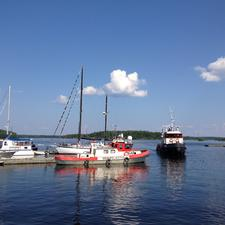
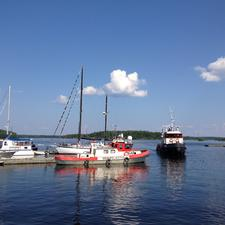

In [30]:
bunch = GGBunch()
bunch.add_plot(i_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(i_plot + ggtitle("classic theme") + theme_classic(), \
               w, 0, w, h)
bunch.show()

In [31]:
pt_plot = ggplot(df, aes('cty', 'hwy')) + \
    geom_point(aes(color='fl'), tooltips=layer_tooltips().anchor('top_center').min_width(50))

bunch = GGBunch()
bunch.add_plot(pt_plot + ggtitle("default"), \
               0, 0, w, h)
bunch.add_plot(pt_plot + ggtitle("gray background") + \
               theme(panel_background=element_rect(color='black', fill='gray')), \
               w, 0, w, h)
bunch.show()

In [32]:
s_plot = ggplot(df, aes('cty', 'hwy')) + \
    geom_point(aes(color='fl'), sampling=sampling_random(20, seed=42))

gggrid([
    s_plot + ggtitle("default"),
    s_plot + ggtitle("blank plot message") + theme(plot_message='blank')
])

In [33]:
l_plot = ggplot(df) + \
    geom_bar(aes('fl', color='fl', fill='fl'), labels=layer_labels().line('@..sumpct..'))

gggrid([
    l_plot + ggtitle("default"),
    l_plot + ggtitle("specified label_text") + theme(label_text=element_text(family='Times', face='bold', size=11))
])

In [34]:
e_plot = b_plot + scale_y_continuous(format='.3~e')

gggrid([
    e_plot + ggtitle("default"),
    e_plot + ggtitle("specified exponent_format") + theme(exponent_format='pow')
])